In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


print(" CROP YIELD PREDICTION - ML WORKFLOW")


 CROP YIELD PREDICTION - ML WORKFLOW


In [4]:
# Load the dataset
df = pd.read_csv('C:\\Users\\Divine\\OneDrive\\Desktop\\RECESS 2025-26\\Week6\\farmers_dataset.csv')

print("\n STEP 1: DATA LOADING & EXPLORATION")
print("-" * 50)
print(f" Dataset loaded successfully!")
print(f" Shape: {df.shape[0]} farmers, {df.shape[1]} features")

# Display basic information
print("\n Column Information:")
df.info()

# Show first 5 rows to understand data structure
print("\n First 5 Farmers:")
print(df.head())

# Check for missing values
print("\n Missing Values Check:")
print(df.isnull().sum())

# Statistical summary of numerical columns
print("\n Statistical Summary (Numerical Features):")
print(df.describe().round(2))



 STEP 1: DATA LOADING & EXPLORATION
--------------------------------------------------
 Dataset loaded successfully!
 Shape: 1000 farmers, 13 features

 Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   FarmerID            1000 non-null   str    
 1   District            1000 non-null   str    
 2   Region              1000 non-null   str    
 3   CropType            1000 non-null   str    
 4   FarmSizeAcres       1000 non-null   float64
 5   SoilType            1000 non-null   str    
 6   RainfallMM          1000 non-null   int64  
 7   SoilMoisture        1000 non-null   int64  
 8   FertilizerKG        1000 non-null   int64  
 9   TemperatureC        1000 non-null   float64
 10  MarketDistanceKM    1000 non-null   float64
 11  Irrigation          1000 non-null   str    
 12  HarvestYieldTonnes  1000 non-null   floa

In [5]:
print("\n STEP 2: DATA CLEANING & PREPROCESSING")


# 3.1: Check for and handle missing values
print("\n Checking for missing values...")
missing_before = df.isnull().sum().sum()
print(f"   Missing values before cleaning: {missing_before}")

# In this dataset, there are no missing values, but let's show the process
df_clean = df.copy()  # Create a copy to preserve original



 STEP 2: DATA CLEANING & PREPROCESSING

 Checking for missing values...
   Missing values before cleaning: 0


In [6]:
# 3.3: Drop original categorical columns (keep encoded versions)
df_clean = df_clean.drop(columns=['District', 'Region', 'CropType', 'SoilType', 'Irrigation'])


In [12]:
print("\n Encoding Categorical Variables...")

label_encoders = {}
categorical_columns = ['District', 'Region', 'CropType', 'SoilType', 'Irrigation']

for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"    Encoded '{col}': {len(le.classes_)} unique values")


 Encoding Categorical Variables...
    Encoded 'District': 15 unique values
    Encoded 'Region': 4 unique values
    Encoded 'CropType': 8 unique values
    Encoded 'SoilType': 3 unique values
    Encoded 'Irrigation': 2 unique values


In [13]:
print("\n Feature Engineering...")

# Create yield efficiency (yield per acre)
df_clean['YieldEfficiency'] = df_clean['HarvestYieldTonnes'] / df_clean['FarmSizeAcres']

# Create fertilizer efficiency
df_clean['FertilizerEfficiency'] = df_clean['HarvestYieldTonnes'] / (df_clean['FertilizerKG'] + 1)

# Create water availability score
df_clean['WaterScore'] = df_clean['RainfallMM'] * df_clean['SoilMoisture'] / 1000

# Create total input score (combining factors)
df_clean['InputScore'] = (df_clean['FertilizerKG'] + df_clean['RainfallMM'] / 10 + df_clean['SoilMoisture']) / 100

print(f"    Added 4 new engineered features")
print(f"    Dataset shape after preprocessing: {df_clean.shape}")

# Display cleaned data
print("\n Cleaned Data Sample:")
print(df_clean.head())


 Feature Engineering...
    Added 4 new engineered features
    Dataset shape after preprocessing: (1000, 17)

 Cleaned Data Sample:
  FarmerID  FarmSizeAcres  RainfallMM  SoilMoisture  FertilizerKG  \
0    F0001           10.2         798            29           420   
1    F0002           11.1         843            50            46   
2    F0003           14.6        1512            26           499   
3    F0004           14.5        1847            43            52   
4    F0005           15.7        1716            88           218   

   TemperatureC  MarketDistanceKM  HarvestYieldTonnes  District  Region  \
0          26.0              29.9                5.65         2       2   
1          26.3               5.7                7.41         7       0   
2          21.3              45.0                9.93         9       0   
3          26.7              51.5               10.67         6       3   
4          29.7              37.8               10.13        14       0   




 STEP 3: EXPLORATORY DATA ANALYSIS


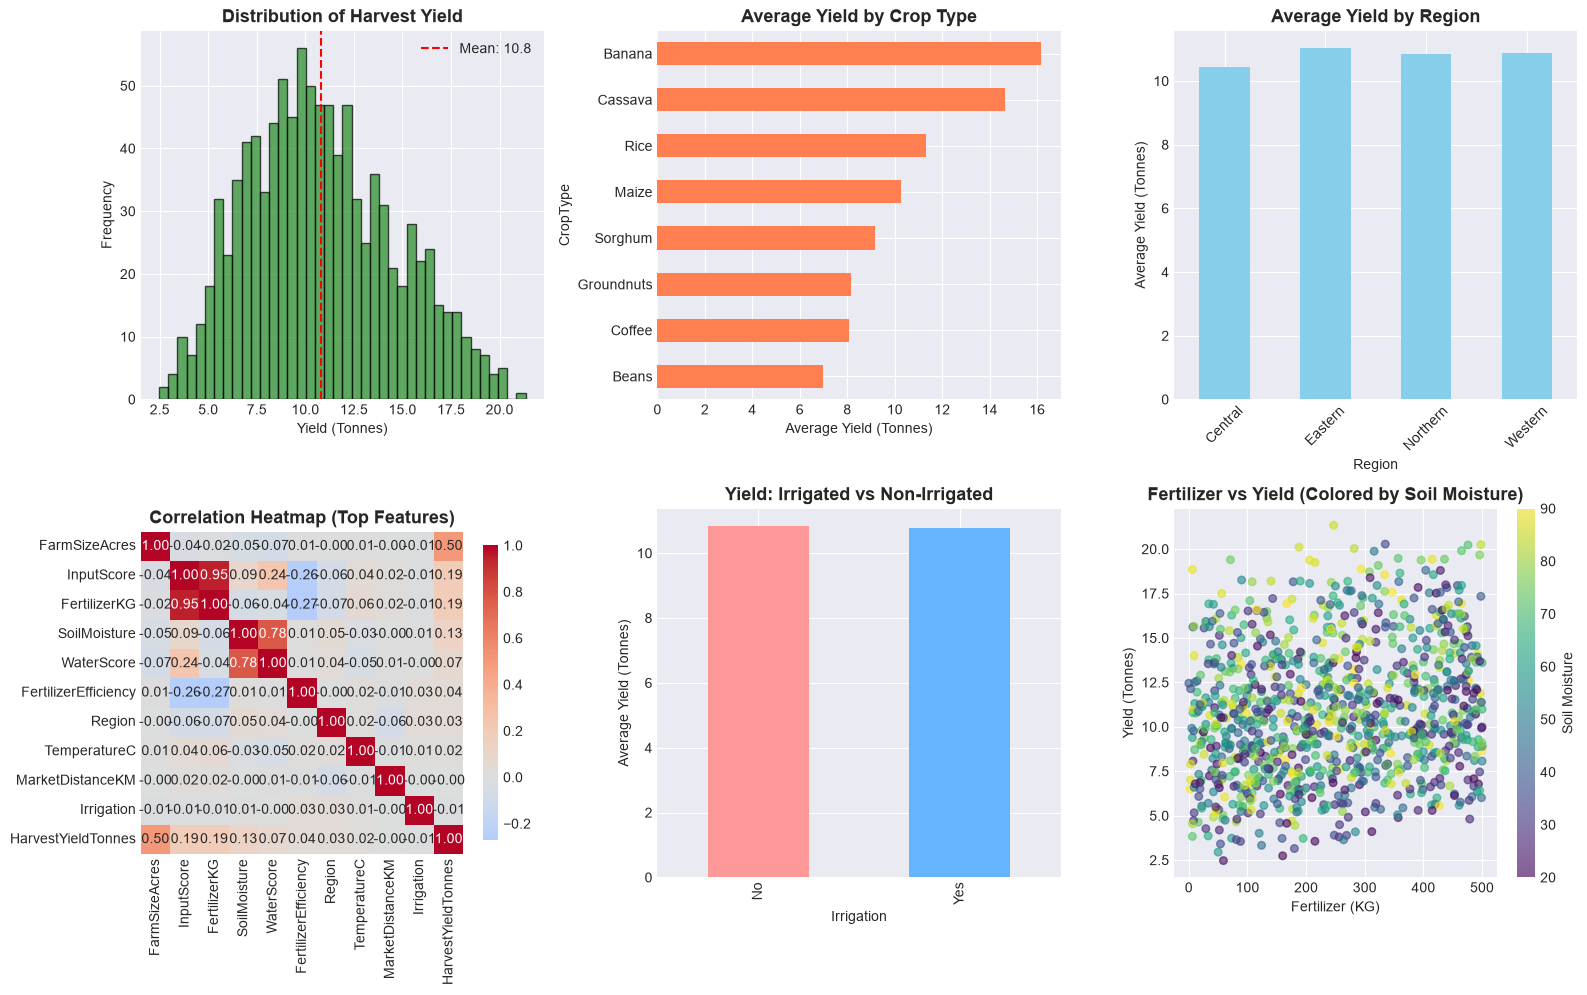


 EDA Visualizations saved as 'agriculture_eda.png'

 Feature Statistics:
       FarmSizeAcres  RainfallMM  SoilMoisture  FertilizerKG  TemperatureC  \
count        1000.00     1000.00       1000.00       1000.00       1000.00   
mean           12.49     1453.72         54.69        247.96         25.40   
std             7.12      432.64         20.83        146.01          4.41   
min             0.50      700.00         20.00          0.00         18.00   
25%             6.20     1077.00         36.00        117.00         21.40   
50%            12.35     1448.00         55.00        242.50         25.60   
75%            18.50     1810.00         72.00        382.00         29.30   
max            25.00     2197.00         90.00        500.00         33.00   

       MarketDistanceKM  HarvestYieldTonnes  District   Region  CropType  \
count           1000.00             1000.00   1000.00  1000.00   1000.00   
mean              41.11               10.80      6.93     1.53      3.5

In [14]:
print("\n STEP 3: EXPLORATORY DATA ANALYSIS")


# 4.1: Distribution of Target Variable
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Target distribution
ax1 = axes[0, 0]
ax1.hist(df_clean['HarvestYieldTonnes'], bins=40, edgecolor='black', alpha=0.7, color='forestgreen')
ax1.set_title('Distribution of Harvest Yield', fontsize=13, fontweight='bold')
ax1.set_xlabel('Yield (Tonnes)')
ax1.set_ylabel('Frequency')
ax1.axvline(df_clean['HarvestYieldTonnes'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["HarvestYieldTonnes"].mean():.1f}')
ax1.legend()

# 4.2: Yield by Crop Type
ax2 = axes[0, 1]
crop_yield = df.groupby('CropType')['HarvestYieldTonnes'].mean().sort_values()
crop_yield.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Average Yield by Crop Type', fontsize=13, fontweight='bold')
ax2.set_xlabel('Average Yield (Tonnes)')

# 4.3: Yield by Region
ax3 = axes[0, 2]
region_yield = df.groupby('Region')['HarvestYieldTonnes'].mean()
region_yield.plot(kind='bar', ax=ax3, color='skyblue')
ax3.set_title('Average Yield by Region', fontsize=13, fontweight='bold')
ax3.set_xlabel('Region')
ax3.set_ylabel('Average Yield (Tonnes)')
ax3.tick_params(axis='x', rotation=45)

# 4.4: Correlation Heatmap (Top 10 features)
ax4 = axes[1, 0]
# Select numerical columns for correlation
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numerical_cols].corr()
# Get top correlations with target
target_corr = correlation_matrix['HarvestYieldTonnes'].sort_values(ascending=False).head(11)
top_features = target_corr.index[1:]  # Exclude target itself
corr_subset = df_clean[list(top_features) + ['HarvestYieldTonnes']].corr()
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax4, cbar_kws={'shrink': 0.8})
ax4.set_title('Correlation Heatmap (Top Features)', fontsize=13, fontweight='bold')

# 4.5: Irrigation Impact
ax5 = axes[1, 1]
irrigation_data = df.groupby('Irrigation')['HarvestYieldTonnes'].mean()
irrigation_data.plot(kind='bar', ax=ax5, color=['#ff9999','#66b3ff'])
ax5.set_title('Yield: Irrigated vs Non-Irrigated', fontsize=13, fontweight='bold')
ax5.set_xlabel('Irrigation')
ax5.set_ylabel('Average Yield (Tonnes)')

# 4.6: Scatter plot of key relationships
ax6 = axes[1, 2]
scatter = ax6.scatter(df_clean['FertilizerKG'], df_clean['HarvestYieldTonnes'], 
                      c=df_clean['SoilMoisture'], cmap='viridis', alpha=0.6, s=30)
ax6.set_title('Fertilizer vs Yield (Colored by Soil Moisture)', fontsize=13, fontweight='bold')
ax6.set_xlabel('Fertilizer (KG)')
ax6.set_ylabel('Yield (Tonnes)')
plt.colorbar(scatter, ax=ax6, label='Soil Moisture')

plt.tight_layout()
plt.savefig('agriculture_eda.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n EDA Visualizations saved as 'agriculture_eda.png'")

# 4.7: Statistical summary of features
print("\n Feature Statistics:")
print(df_clean.describe().round(2))

In [21]:
print("\n STEP 4: FEATURE SELECTION & DATA SPLITTING")
print("-" * 50)

# 5.1: Define features (X) and target (y)
"""
STUDENT NOTE: Features are the inputs, Target is what we want to predict!
"""
# Select features based on correlation analysis
feature_columns = ['FarmSizeAcres', 'RainfallMM', 'SoilMoisture', 'FertilizerKG', 
                   'TemperatureC', 'MarketDistanceKM']

# Add engineered features
feature_columns.extend(['YieldEfficiency', 'FertilizerEfficiency', 'WaterScore'])

X = df_clean[feature_columns]
y = df_clean['HarvestYieldTonnes']

print(f" Features selected: {len(feature_columns)}")
print(f"   Features: {feature_columns}")
print(f"   Target: HarvestYieldTonnes")

# 5.2: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # random_state ensures reproducibility
)

print(f"\n Data Split:")
print(f"   Training set: {len(X_train)} farmers ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Testing set: {len(X_test)} farmers ({len(X_test)/len(X)*100:.0f}%)")

# 5.3: Scale numerical features
"""
STUDENT NOTE: Scaling helps models converge faster and prevents 
features with large values from dominating!
"""
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Feature Scaling Applied:")
print(f"   Mean before scaling: {X_train['RainfallMM'].mean():.1f}")
print(f"   Mean after scaling: {X_train_scaled[:, 1].mean():.4f}")



 STEP 4: FEATURE SELECTION & DATA SPLITTING
--------------------------------------------------
 Features selected: 9
   Features: ['FarmSizeAcres', 'RainfallMM', 'SoilMoisture', 'FertilizerKG', 'TemperatureC', 'MarketDistanceKM', 'YieldEfficiency', 'FertilizerEfficiency', 'WaterScore']
   Target: HarvestYieldTonnes

 Data Split:
   Training set: 800 farmers (80%)
   Testing set: 200 farmers (20%)

 Feature Scaling Applied:
   Mean before scaling: 1444.0
   Mean after scaling: -0.0000


In [22]:
print("\n STEP 5: MODEL TRAINING")
print("-" * 50)

# 6.1: Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

# 6.2: Train models and collect results
results = {}

print("\n Training Models...\n")
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions on training and test sets
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'y_pred': y_test_pred
    }
    
    print(f" {name}:")
    print(f"   Train R²: {train_r2:.4f}")
    print(f"   Test R²: {test_r2:.4f}")
    print(f"   Test MSE: {test_mse:.2f}")
    print(f"   Test MAE: {test_mae:.2f}")
    print()



 STEP 5: MODEL TRAINING
--------------------------------------------------

 Training Models...

 Linear Regression:
   Train R²: 0.3996
   Test R²: 0.3675
   Test MSE: 7.73
   Test MAE: 2.25

 Ridge Regression:
   Train R²: 0.3996
   Test R²: 0.3673
   Test MSE: 7.73
   Test MAE: 2.25

 Lasso Regression:
   Train R²: 0.1788
   Test R²: 0.1936
   Test MSE: 9.86
   Test MAE: 2.55

 Decision Tree:
   Train R²: 0.9970
   Test R²: 0.9138
   Test MSE: 1.05
   Test MAE: 0.73

 Random Forest:
   Train R²: 0.9945
   Test R²: 0.9680
   Test MSE: 0.39
   Test MAE: 0.41

 Gradient Boosting:
   Train R²: 0.9986
   Test R²: 0.9750
   Test MSE: 0.31
   Test MAE: 0.39




 STEP 6: MODEL EVALUATION & COMPARISON

 Model Performance Comparison:
            Model  Train R²  Test R²  Test MSE  Test MAE
Gradient Boosting  0.998617 0.975035  0.305133  0.388799
    Random Forest  0.994547 0.967986  0.391284  0.413442
    Decision Tree  0.996965 0.913752  1.054144  0.727476
Linear Regression  0.399579 0.367473  7.730874  2.252001
 Ridge Regression  0.399571 0.367255  7.733542  2.252207
 Lasso Regression  0.178771 0.193560  9.856474  2.545869

 Best Model: Gradient Boosting
   Test R² Score: 0.9750
   Test MAE: 0.39 tonnes

 Feature Importance Analysis (Random Forest):
   FarmSizeAcres: 0.4592
   YieldEfficiency: 0.4022
   FertilizerEfficiency: 0.0624
   FertilizerKG: 0.0505
   SoilMoisture: 0.0064
   TemperatureC: 0.0053
   MarketDistanceKM: 0.0051
   WaterScore: 0.0047
   RainfallMM: 0.0042


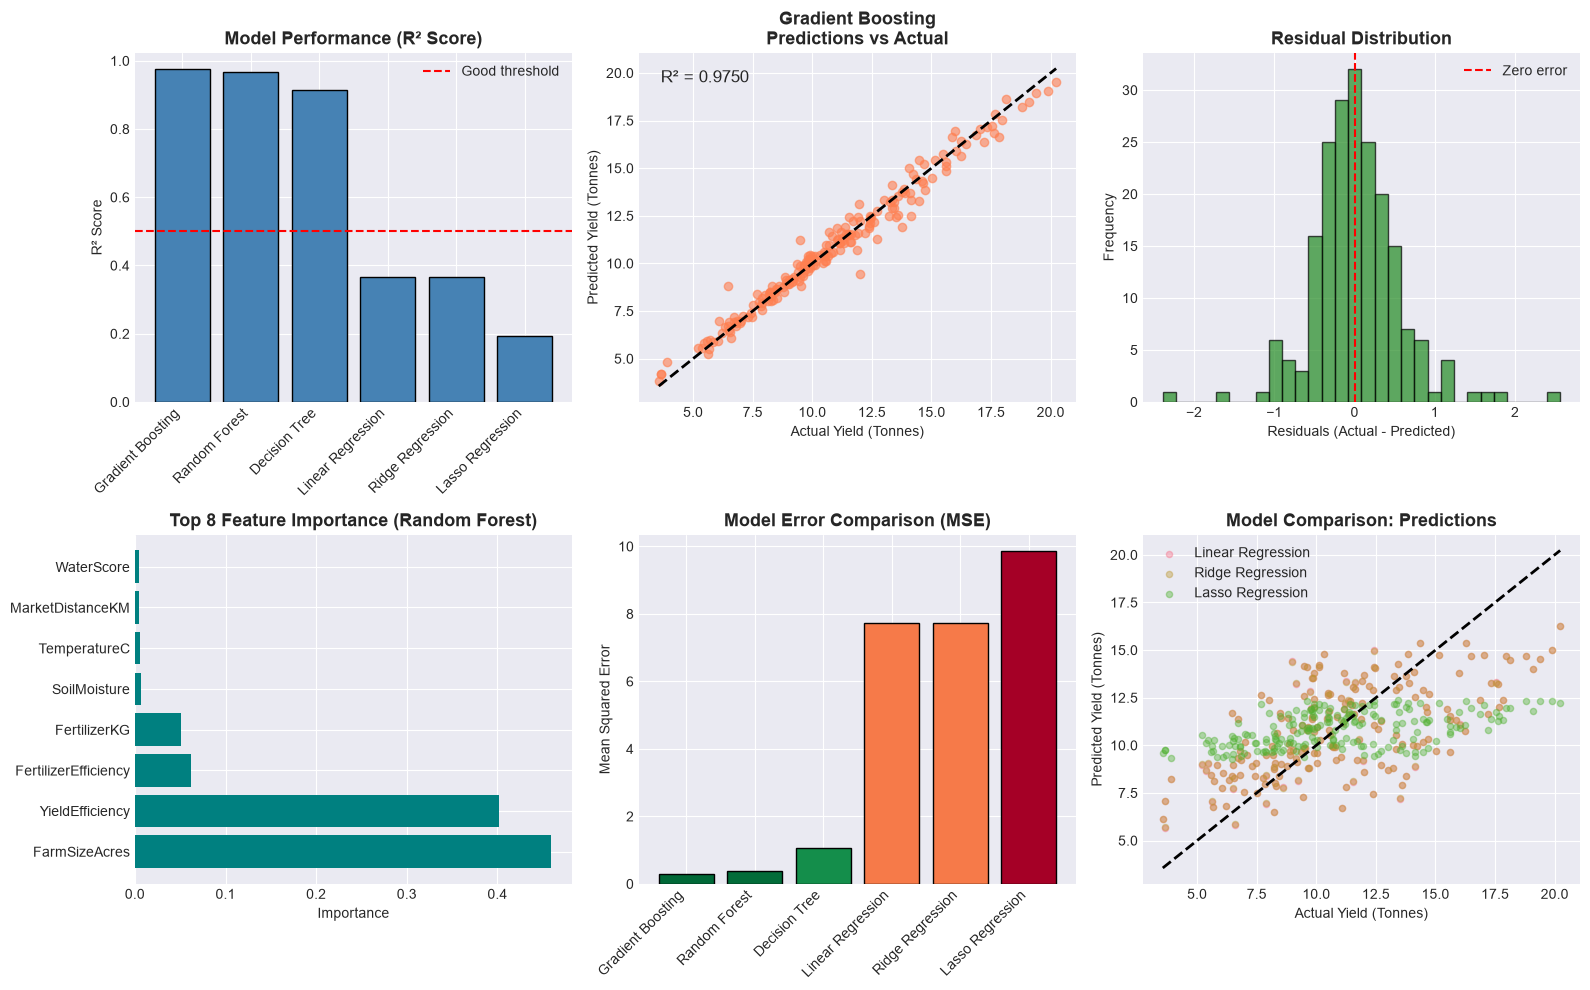


 Model evaluation visualizations saved as 'model_evaluation.png'


In [23]:
print("\n STEP 6: MODEL EVALUATION & COMPARISON")


# 7.1: Create results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train R²': [results[m]['train_r2'] for m in results],
    'Test R²': [results[m]['test_r2'] for m in results],
    'Test MSE': [results[m]['test_mse'] for m in results],
    'Test MAE': [results[m]['test_mae'] for m in results]
})
results_df = results_df.sort_values('Test R²', ascending=False)
print("\n Model Performance Comparison:")
print(results_df.to_string(index=False))

# 7.2: Identify best model
best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\n Best Model: {best_model_name}")
print(f"   Test R² Score: {results_df.iloc[0]['Test R²']:.4f}")
print(f"   Test MAE: {results_df.iloc[0]['Test MAE']:.2f} tonnes")

# 7.3: Feature importance from Random Forest
print("\n Feature Importance Analysis (Random Forest):")
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

for idx, row in feature_importance_df.head(10).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

# 7.4: Visualize model performance
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Model Comparison Bar Chart
ax1 = axes[0, 0]
x_pos = np.arange(len(results_df))
ax1.bar(x_pos, results_df['Test R²'], color='steelblue', edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.set_title('Model Performance (R² Score)', fontsize=13, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.axhline(y=0.5, color='red', linestyle='--', label='Good threshold')
ax1.legend()

# Plot 2: Actual vs Predicted for Best Model
ax2 = axes[0, 1]
y_pred_best = results[best_model_name]['y_pred']
ax2.scatter(y_test, y_pred_best, alpha=0.6, color='coral')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax2.set_xlabel('Actual Yield (Tonnes)')
ax2.set_ylabel('Predicted Yield (Tonnes)')
ax2.set_title(f'{best_model_name}\nPredictions vs Actual', fontsize=13, fontweight='bold')
ax2.text(0.05, 0.95, f'R² = {results[best_model_name]["test_r2"]:.4f}', 
         transform=ax2.transAxes, fontsize=12, verticalalignment='top')

# Plot 3: Residuals Distribution
ax3 = axes[0, 2]
residuals = y_test - y_pred_best
ax3.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='forestgreen')
ax3.set_xlabel('Residuals (Actual - Predicted)')
ax3.set_ylabel('Frequency')
ax3.set_title('Residual Distribution', fontsize=13, fontweight='bold')
ax3.axvline(0, color='red', linestyle='--', label='Zero error')
ax3.legend()

# Plot 4: Feature Importance
ax4 = axes[1, 0]
top_features = feature_importance_df.head(8)
ax4.barh(top_features['Feature'], top_features['Importance'], color='teal')
ax4.set_xlabel('Importance')
ax4.set_title('Top 8 Feature Importance (Random Forest)', fontsize=13, fontweight='bold')

# Plot 5: Model Error Comparison
ax5 = axes[1, 1]
mse_values = results_df['Test MSE'].values
colors = plt.cm.RdYlGn_r((mse_values - mse_values.min()) / (mse_values.max() - mse_values.min()))
ax5.bar(x_pos, mse_values, color=colors, edgecolor='black')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax5.set_title('Model Error Comparison (MSE)', fontsize=13, fontweight='bold')
ax5.set_ylabel('Mean Squared Error')

# Plot 6: Prediction Error
ax6 = axes[1, 2]
for name in list(results.keys())[:3]:  # Show top 3 models
    y_pred_model = results[name]['y_pred']
    ax6.scatter(y_test, y_pred_model, alpha=0.4, label=name, s=20)
ax6.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax6.set_xlabel('Actual Yield (Tonnes)')
ax6.set_ylabel('Predicted Yield (Tonnes)')
ax6.set_title('Model Comparison: Predictions', fontsize=13, fontweight='bold')
ax6.legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Model evaluation visualizations saved as 'model_evaluation.png'")


In [24]:
print("\n STEP 7: CROSS-VALIDATION")


# Perform 5-fold cross-validation on the best model
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='r2')

print(f" Cross-Validation Results ({best_model_name}):")
print(f"   CV Scores: {cv_scores}")
print(f"   Mean CV Score: {cv_scores.mean():.4f}")
print(f"   Std Dev: {cv_scores.std():.4f}")



 STEP 7: CROSS-VALIDATION
 Cross-Validation Results (Gradient Boosting):
   CV Scores: [0.98067947 0.97087572 0.97399714 0.97089869 0.97150295]
   Mean CV Score: 0.9736
   Std Dev: 0.0037


In [27]:
print("\n STEP 8: MAKING PREDICTIONS FOR NEW FARMS")


# Create sample data for 3 new farms
new_farms = pd.DataFrame({
    'FarmSizeAcres': [15.0, 20.0, 8.0],
    'RainfallMM': [1200, 1500, 900],
    'SoilMoisture': [60, 45, 80],
    'FertilizerKG': [300, 200, 400],
    'TemperatureC': [25, 28, 22],
    'MarketDistanceKM': [30, 15, 50],
    'Region_Encoded': [0, 1, 2],  # 0: Central, 1: Eastern, 2: Northern
    'SoilType_Encoded': [0, 1, 2],  # 0: Clay, 1: Loam, 2: Sandy
    'Irrigation_Encoded': [1, 0, 1],  # 1: Yes, 0: No
    'YieldEfficiency': [0.5, 0.6, 0.7],
    'FertilizerEfficiency': [0.02, 0.025, 0.015],
    'WaterScore': [72, 67.5, 72]
})

# Scale the new data
new_farms_scaled = scaler.transform(new_farms[feature_columns])

# Make predictions
predictions = best_model.predict(new_farms_scaled)

print("\n Predicted Yields for New Farms:")
for i in range(len(new_farms)):
    print(f"   Farm {i+1}: {predictions[i]:.2f} tonnes per acre")
    print(f"      Farm Size: {new_farms.iloc[i]['FarmSizeAcres']} acres")
    print(f"      Total Expected: {predictions[i] * new_farms.iloc[i]['FarmSizeAcres']:.2f} tonnes")



 STEP 8: MAKING PREDICTIONS FOR NEW FARMS

 Predicted Yields for New Farms:
   Farm 1: 7.62 tonnes per acre
      Farm Size: 15.0 acres
      Total Expected: 114.28 tonnes
   Farm 2: 11.87 tonnes per acre
      Farm Size: 20.0 acres
      Total Expected: 237.43 tonnes
   Farm 3: 5.88 tonnes per acre
      Farm Size: 8.0 acres
      Total Expected: 47.06 tonnes


In [28]:
print(" SUMMARY & KEY LEARNINGS")


print("""
 MACHINE LEARNING WORKFLOW COMPLETED SUCCESSFULLY!

 KEY LEARNINGS:
1.  DATA EXPLORATION: Understand your data before modeling
2.  DATA CLEANING: Handle missing values, encode categories
3.  FEATURE ENGINEERING: Create new features to improve predictions
4.  DATA SPLITTING: Train on 80%, Test on 20%
5.  MODEL TRAINING: Try multiple algorithms
6.  MODEL EVALUATION: Use R², MSE, MAE metrics
7.  CROSS-VALIDATION: Test model robustness
8.  PREDICTIONS: Use trained model on new data

 BEST PERFORMING MODEL:
- Model: {best_model_name}
- R² Score: {results[best_model_name]['test_r2']:.4f}
- Interpretation: {results[best_model_name]['test_r2']*100:.1f}% of yield variance is explained

 MOST IMPORTANT FEATURES:
""")

# Show top 5 features
top_5 = feature_importance_df.head(5)
for idx, row in top_5.iterrows():
    print(f"   - {row['Feature']}: {row['Importance']:.4f}")

print("""
 BUSINESS INSIGHTS:
- Farmers can use this model to predict yields BEFORE planting
- Identifies which factors most affect yield (investment areas)
- Helps optimize fertilizer and irrigation usage
- Guides regional crop selection decisions

 NEXT STEPS FOR STUDENTS:
1. Try different feature engineering combinations
2. Experiment with hyperparameter tuning
3. Test with different algorithms (XGBoost, SVM)
4. Deploy model using Flask/FastAPI
""")


print(" HAPPY MACHINE LEARNING!")

 SUMMARY & KEY LEARNINGS

 MACHINE LEARNING WORKFLOW COMPLETED SUCCESSFULLY!

 KEY LEARNINGS:
1.  DATA EXPLORATION: Understand your data before modeling
2.  DATA CLEANING: Handle missing values, encode categories
3.  FEATURE ENGINEERING: Create new features to improve predictions
4.  DATA SPLITTING: Train on 80%, Test on 20%
5.  MODEL TRAINING: Try multiple algorithms
6.  MODEL EVALUATION: Use R², MSE, MAE metrics
7.  CROSS-VALIDATION: Test model robustness
8.  PREDICTIONS: Use trained model on new data

 BEST PERFORMING MODEL:
- Model: {best_model_name}
- R² Score: {results[best_model_name]['test_r2']:.4f}
- Interpretation: {results[best_model_name]['test_r2']*100:.1f}% of yield variance is explained

 MOST IMPORTANT FEATURES:

   - FarmSizeAcres: 0.4592
   - YieldEfficiency: 0.4022
   - FertilizerEfficiency: 0.0624
   - FertilizerKG: 0.0505
   - SoilMoisture: 0.0064

 BUSINESS INSIGHTS:
- Farmers can use this model to predict yields BEFORE planting
- Identifies which factors most aff